<a href="https://colab.research.google.com/github/ColinLi98/IFT0024/blob/Lecture-1/Final_Tutorial_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, norm, probplot
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Step 1: Upload Data

In [13]:
try:
    from google.colab import files
    print("Running in Colab - upload Asset_1_prices.csv, Asset_2_prices.csv, Asset_3_prices.csv")
    uploaded = files.upload()
    DATA_PATH = "/content"
except:
    print("Running locally")
    DATA_PATH = "."

Running in Colab - upload Asset_1_prices.csv, Asset_2_prices.csv, Asset_3_prices.csv


Saving Asset_1_prices.csv to Asset_1_prices (2).csv
Saving Asset_2_prices.csv to Asset_2_prices (2).csv
Saving Asset_3_prices.csv to Asset_3_prices (2).csv


In [14]:
# Load data
assets = {}
for i in range(1, 4):
    df = pd.read_csv(f"{DATA_PATH}/Asset_{i}_prices.csv")
    assets[f'Asset_{i}'] = df['Price'].values
    print(f"✓ Asset_{i}: {len(assets[f'Asset_{i}'])} prices")

✓ Asset_1: 252 prices
✓ Asset_2: 252 prices
✓ Asset_3: 252 prices


## Step 2: Utility Functions

In [15]:
def calc_returns(prices):
    return np.diff(np.log(prices))

def split_into_7(prices):
    n = len(prices)
    chunk = n // 7
    return {i+1: prices[i*chunk:min((i+1)*chunk+1, n)].copy() for i in range(7)}

def get_sources(group, round_num):
    return [((group - 1 + r - 1) % 7) + 1 for r in range(1, round_num + 1)]

def merge_data(splits, group, round_num):
    sources = get_sources(group, round_num)
    all_ret = []
    for src in sources:
        all_ret.extend(calc_returns(splits[src]))
    return np.array(all_ret)

def black_scholes(S, K, T, r, sigma, opt='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if opt == 'call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def evaluate_strategies(returns, n_sim=5000):
    S0, sigma = 100, np.std(returns)*np.sqrt(252)
    call = black_scholes(S0, S0, 1, 0, sigma, 'call')
    put = black_scholes(S0, S0, 1, 0, sigma, 'put')
    straddle_cost = call + put
    K_put = S0*(1 - 0.5*sigma)
    prot_put_cost = S0 + black_scholes(S0, K_put, 1, 0, sigma, 'put')

    results = {'Straddle': [], 'Protective_Put': [], 'Buy_Hold': []}
    for _ in range(n_sim):
        S_T = S0 * np.exp(np.sum(np.random.choice(returns, 252, replace=True)))
        results['Straddle'].append(np.log(abs(S_T-S0)/straddle_cost) if abs(S_T-S0) > 0 else -10)
        results['Protective_Put'].append(np.log(max(S_T, K_put)/prot_put_cost))
        results['Buy_Hold'].append(np.log(S_T/S0))
    return {k: np.mean(v) for k, v in results.items()}

## Step 3: Ground Truth (Full Dataset)

In [16]:
print("="*70)
print("GROUND TRUTH")
print("="*70)

for name, prices in assets.items():
    ret = calc_returns(prices)
    print(f"\n{name}:")
    print(f"  Skewness: {skew(ret):+.4f}")
    print(f"  Kurtosis: {kurtosis(ret):+.4f}")
    print(f"  Ann Vol:  {np.std(ret)*np.sqrt(252):.4f}")

GROUND TRUTH

Asset_1:
  Skewness: +0.3057
  Kurtosis: +0.5752
  Ann Vol:  0.2417

Asset_2:
  Skewness: -0.8554
  Kurtosis: +0.7357
  Ann Vol:  0.2511

Asset_3:
  Skewness: -0.1871
  Kurtosis: +1.6825
  Ann Vol:  0.2404


## Step 4: Split Data & Save Files

In [17]:
all_splits = {name: split_into_7(prices) for name, prices in assets.items()}

# Create directories and save
for cycle, (asset_name, splits) in enumerate(all_splits.items(), 1):
    dir_name = f"Cycle_{cycle}_{asset_name}"
    os.makedirs(dir_name, exist_ok=True)
    print(f"\n{dir_name}:")
    for g, data in splits.items():
        pd.DataFrame({'Price': data}).to_csv(f"{dir_name}/Group_{g}.csv", index=False)
        print(f"  Group_{g}.csv: {len(data)} prices, {len(data)-1} returns")


Cycle_1_Asset_1:
  Group_1.csv: 37 prices, 36 returns
  Group_2.csv: 37 prices, 36 returns
  Group_3.csv: 37 prices, 36 returns
  Group_4.csv: 37 prices, 36 returns
  Group_5.csv: 37 prices, 36 returns
  Group_6.csv: 37 prices, 36 returns
  Group_7.csv: 36 prices, 35 returns

Cycle_2_Asset_2:
  Group_1.csv: 37 prices, 36 returns
  Group_2.csv: 37 prices, 36 returns
  Group_3.csv: 37 prices, 36 returns
  Group_4.csv: 37 prices, 36 returns
  Group_5.csv: 37 prices, 36 returns
  Group_6.csv: 37 prices, 36 returns
  Group_7.csv: 36 prices, 35 returns

Cycle_3_Asset_3:
  Group_1.csv: 37 prices, 36 returns
  Group_2.csv: 37 prices, 36 returns
  Group_3.csv: 37 prices, 36 returns
  Group_4.csv: 37 prices, 36 returns
  Group_5.csv: 37 prices, 36 returns
  Group_6.csv: 37 prices, 36 returns
  Group_7.csv: 36 prices, 35 returns


## Step 5: Test ALL 7 Groups × ALL 3 Rounds × ALL 3 Cycles

In [18]:
print("="*100)
print("COMPREHENSIVE TEST: ALL GROUPS × ALL ROUNDS × ALL CYCLES")
print("="*100)

all_results = []

for cycle, (asset_name, splits) in enumerate(all_splits.items(), 1):
    print(f"\n{'='*100}")
    print(f"CYCLE {cycle}: {asset_name}")
    print(f"{'='*100}")

    for round_num in range(1, 4):
        print(f"\n--- Round {round_num} ---")
        print(f"{'Group':<8} {'N':<6} {'Skew':<10} {'Kurt':<10} {'Straddle':<12} {'ProtPut':<12} {'BuyHold':<12} {'Best'}")
        print("-"*90)

        for group in range(1, 8):
            merged = merge_data(splits, group, round_num)
            s, k = skew(merged), kurtosis(merged)
            means = evaluate_strategies(merged, n_sim=3000)
            best = max(means, key=means.get)

            print(f"Group_{group:<3} {len(merged):<6} {s:+.4f}    {k:+.4f}    "
                  f"{means['Straddle']:+.4f}      {means['Protective_Put']:+.4f}      "
                  f"{means['Buy_Hold']:+.4f}      {best}")

            all_results.append({
                'Cycle': cycle, 'Asset': asset_name, 'Round': round_num, 'Group': group,
                'N': len(merged), 'Skew': s, 'Kurt': k,
                'Straddle': means['Straddle'], 'ProtPut': means['Protective_Put'],
                'BuyHold': means['Buy_Hold'], 'Best': best
            })

COMPREHENSIVE TEST: ALL GROUPS × ALL ROUNDS × ALL CYCLES

CYCLE 1: Asset_1

--- Round 1 ---
Group    N      Skew       Kurt       Straddle     ProtPut      BuyHold      Best
------------------------------------------------------------------------------------------
Group_1   36     +0.3215    -0.3554    +0.7677      -0.1597      -0.5784      Straddle
Group_2   36     -0.2671    -0.6649    -0.3361      -0.0665      -0.1128      Protective_Put
Group_3   36     -0.3538    +0.8356    -0.0065      -0.1234      -0.2596      Straddle
Group_4   36     +0.3314    -0.3660    -0.3922      +0.0256      +0.0306      Buy_Hold
Group_5   36     +0.3801    -0.0226    +2.1735      +0.9445      +0.9847      Straddle
Group_6   36     +1.0685    +3.3459    +1.2850      +0.5461      +0.5886      Straddle
Group_7   35     +0.3141    -0.1482    -0.3932      -0.0681      -0.1154      Protective_Put

--- Round 2 ---
Group    N      Skew       Kurt       Straddle     ProtPut      BuyHold      Best
---------------

## Step 6: Summary & Validation

In [19]:
df = pd.DataFrame(all_results)

print("="*100)
print("ROUND 3 SUMMARY (Final Trading Round)")
print("="*100)

round3 = df[df['Round'] == 3]

for cycle in [1, 2, 3]:
    cycle_data = round3[round3['Cycle'] == cycle]
    asset = cycle_data['Asset'].iloc[0]

    print(f"\nCycle {cycle} ({asset}):")
    print(f"{'Group':<8} {'Best Strategy':<18} {'Has Positive Return?'}")
    print("-"*50)

    tradeable = 0
    for _, row in cycle_data.iterrows():
        has_pos = max(row['Straddle'], row['ProtPut'], row['BuyHold']) > -0.1
        status = "✓ YES" if has_pos else "✗ NO"
        if has_pos:
            tradeable += 1
        print(f"Group_{row['Group']:<3} {row['Best']:<18} {status}")

    print(f"\n  → {tradeable}/7 groups can trade profitably")

ROUND 3 SUMMARY (Final Trading Round)

Cycle 1 (Asset_1):
Group    Best Strategy      Has Positive Return?
--------------------------------------------------
Group_1   Straddle           ✓ YES
Group_2   Protective_Put     ✓ YES
Group_3   Buy_Hold           ✓ YES
Group_4   Straddle           ✓ YES
Group_5   Straddle           ✓ YES
Group_6   Protective_Put     ✓ YES
Group_7   Straddle           ✓ YES

  → 7/7 groups can trade profitably

Cycle 2 (Asset_2):
Group    Best Strategy      Has Positive Return?
--------------------------------------------------
Group_1   Straddle           ✓ YES
Group_2   Straddle           ✓ YES
Group_3   Straddle           ✓ YES
Group_4   Buy_Hold           ✓ YES
Group_5   Straddle           ✓ YES
Group_6   Straddle           ✓ YES
Group_7   Straddle           ✓ YES

  → 7/7 groups can trade profitably

Cycle 3 (Asset_3):
Group    Best Strategy      Has Positive Return?
--------------------------------------------------
Group_1   Protective_Put     ✓ YES
Gro

In [20]:
# Save results
df.to_csv('all_groups_results.csv', index=False)
print("\n✓ Results saved to: all_groups_results.csv")

# Final validation
round3_data = df[df['Round'] == 3]
tradeable = sum(round3_data.apply(lambda r: max(r['Straddle'], r['ProtPut'], r['BuyHold']) > -0.1, axis=1))

print(f"\n{'='*100}")
print(f"FINAL RESULT: {tradeable}/21 groups ({tradeable/21*100:.1f}%) have tradeable signals at Round 3")
print(f"{'='*100}")

if tradeable >= 20:
    print("\n✓ DATA IS READY FOR TUTORIAL - All groups can participate in trading!")
else:
    print("\n⚠ Some groups may have difficulty - review results above")


✓ Results saved to: all_groups_results.csv

FINAL RESULT: 21/21 groups (100.0%) have tradeable signals at Round 3

✓ DATA IS READY FOR TUTORIAL - All groups can participate in trading!


## Step 7: Visualizations

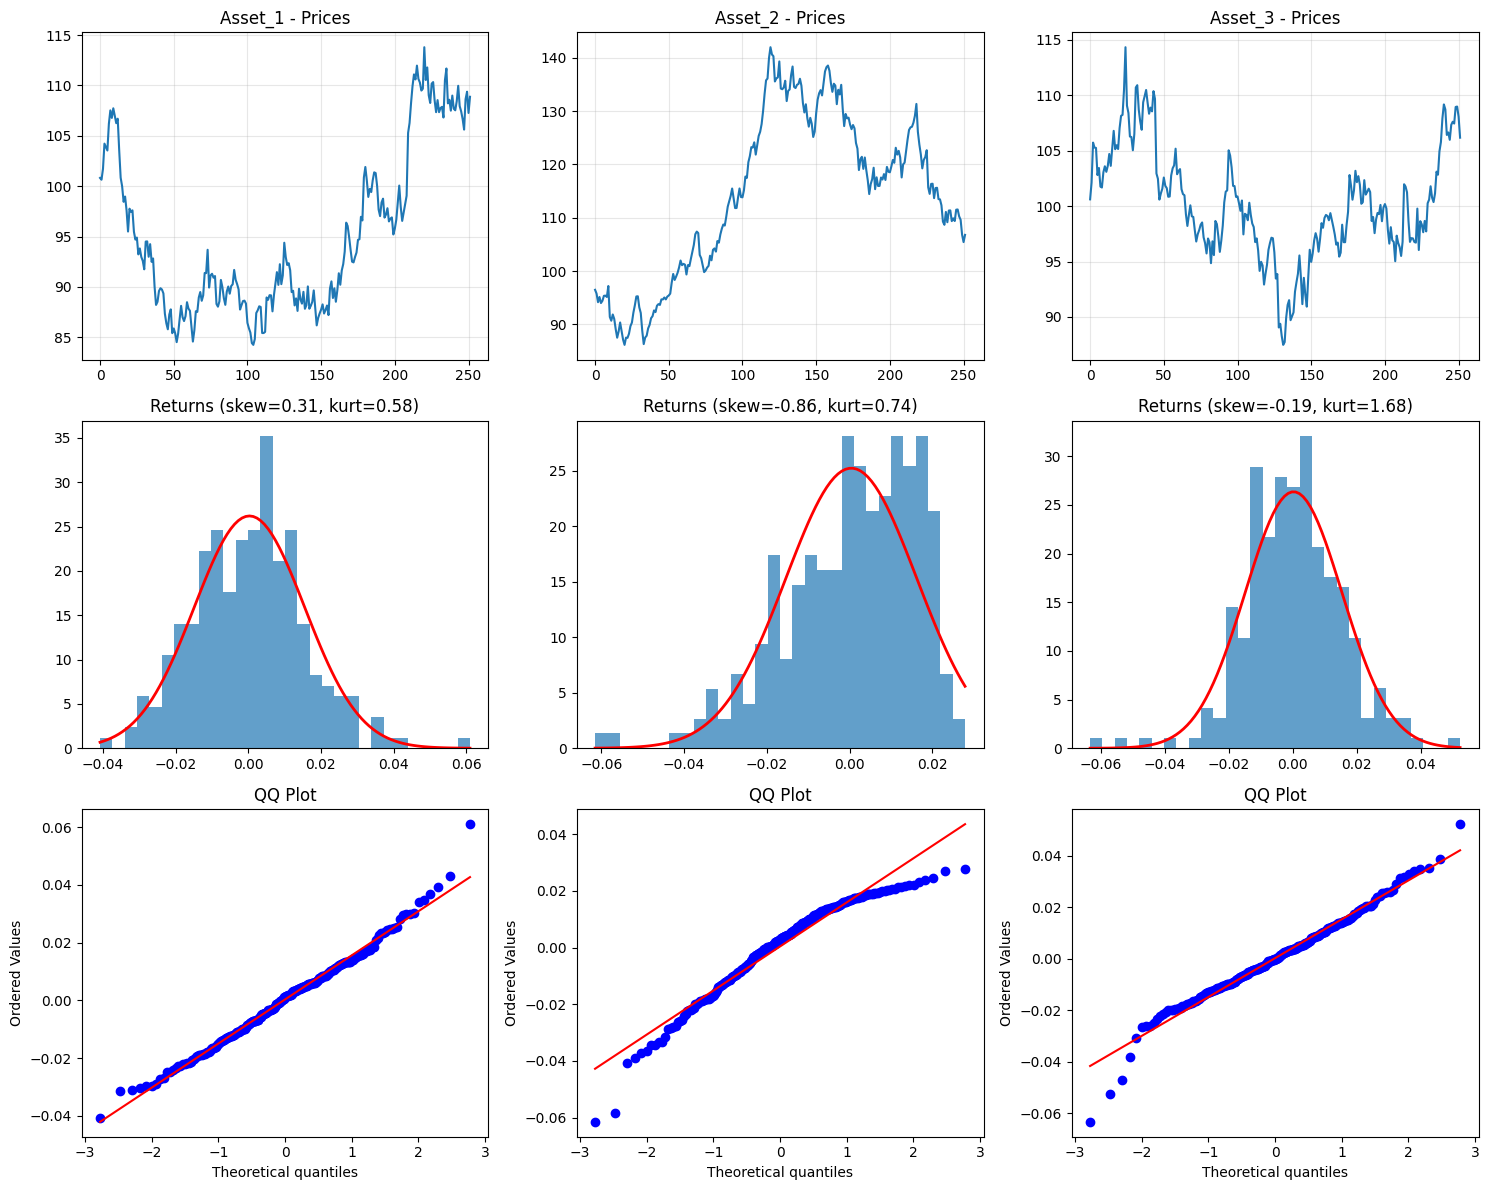

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, (name, prices) in enumerate(assets.items()):
    ret = calc_returns(prices)

    axes[0, idx].plot(prices)
    axes[0, idx].set_title(f'{name} - Prices')
    axes[0, idx].grid(True, alpha=0.3)

    axes[1, idx].hist(ret, bins=30, density=True, alpha=0.7)
    x = np.linspace(min(ret), max(ret), 100)
    axes[1, idx].plot(x, norm.pdf(x, np.mean(ret), np.std(ret)), 'r-', lw=2)
    axes[1, idx].set_title(f'Returns (skew={skew(ret):.2f}, kurt={kurtosis(ret):.2f})')

    probplot(ret, dist="norm", plot=axes[2, idx])
    axes[2, idx].set_title('QQ Plot')

plt.tight_layout()
plt.savefig('analysis.png', dpi=150)
plt.show()

## Step 8: Download Files (Colab)

In [22]:
import shutil

# Create zip of all cycle folders
for cycle in [1, 2, 3]:
    asset = f"Asset_{cycle}"
    shutil.make_archive(f"Cycle_{cycle}_{asset}", 'zip', f"Cycle_{cycle}_{asset}")

# Download in Colab
try:
    from google.colab import files
    for cycle in [1, 2, 3]:
        files.download(f"Cycle_{cycle}_Asset_{cycle}.zip")
    files.download('all_groups_results.csv')
    files.download('analysis.png')
    print("✓ Downloads started")
except:
    print("Files saved locally")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads started


## Answer Key

**Cycle 1 (Asset_1):** Near-Gaussian, positive drift → **Buy-and-Hold**

**Cycle 2 (Asset_2):** Negative skew (-0.86) → **Protective Put**

**Cycle 3 (Asset_3):** Fat tails (kurtosis +1.68) → **Straddle** (or Buy-Hold due to positive drift)
